
# <span style="color:rgb(213,80,0)">FIR Beamformer</span>

Use an FIR filter design method to design a beamformer pointing toward $[-30^{\circ } ,30^{\circ } ]$ .


In [1]:
clc
clear
close all


Assume a 10\-element uniform linear array with a wavelength of 3 cm and half\-wavelength element spacing.


In [2]:
lambda = 3e-2;
num_sensors = 10;
d = 0:lambda/2:(num_sensors-1)*lambda/2;


Create the steering vector


In [3]:
theta = -90:1:90;
A = exp(-1i*2*pi*d.'*sin(deg2rad(theta))/lambda);


Compute the beamformer weights


In [4]:
%% 4. Design weights using the FIR equiripple method
% Design specifications from the textbook：
% Passband：theta ∈ [-30°, 30°]
% Stopband：theta ∈ [-90°, -45°] and [45°, 90°]
%
% The normalized FIR frequency and angle satisfy：
% F = Omega/pi = |sin(theta)|

Fp = sind(30);              % 0.5
Fs = sind(45);              % 0.7071

F = [0, Fp, Fs, 1];
D = [1, 1, 0, 0];

% M=10 elements, corresponding to FIR order M-1=9
wH = firpm(num_sensors-1, F, D);

disp('Beamformer weights w^H =');

Beamformer weights w^H =


In [5]:
disp(wH);

    0.0434    0.0397   -0.1219    0.0655    0.5124    0.5124    0.0655   -0.1219    0.0397    0.0434



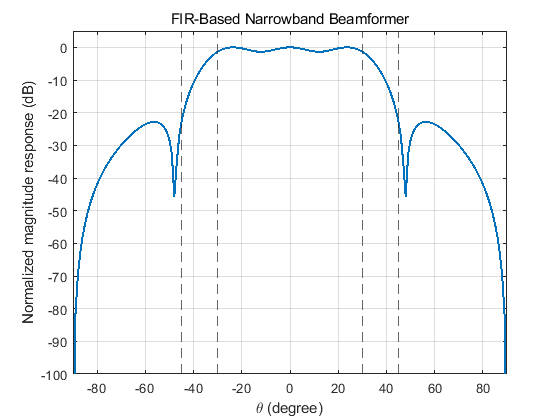

In [6]:

%% 5. Compute the beam response
P = wH * A;

P_abs = abs(P);
P_abs = P_abs / max(P_abs);

BP = 20*log10(max(P_abs, 1e-10));

%% 6. Plot the beam pattern
figure;
plot(theta, BP, 'LineWidth', 1.5);
grid on;

xlim([-90 90]);
ylim([-100 5]);

xlabel('\theta (degree)');
ylabel('Normalized magnitude response (dB)');
title('FIR-Based Narrowband Beamformer');

xline(-45, '--');
xline(-30, '--');
xline(30,  '--');
xline(45,  '--');


Use an FIR filter and complex exponential modulation to generate a $[-60^{\circ } ,-30^{\circ } ]$ bandpass filter.


In [7]:

%% Array parameters
lambda = 3e-2;
M = 10;

theta = -90:0.1:90;
m = (0:M-1).';

%% Steering vector for a half-wavelength-spaced array
A = exp(-1j*pi*m*sind(theta));

%% Target angular interval
theta1 = -60;
theta2 = -30;

u1 = sind(theta1);      % -0.8660
u2 = sind(theta2);      % -0.5000

%% Spatial-frequency center and half-bandwidth
u0 = (u1 + u2)/2;       % -0.6830
Bu = abs(u2-u1)/2;      % 0.1830

%% Design a low-pass prototype centered at zero frequency
Fp = Bu;                % passband half-width
Fs = 0.27;              % adjustable stopband edge

h0 = firpm(M-1, ...
           [0 Fp Fs 1], ...
           [1 1  0  0]);

%% Complex exponential modulation
% Shift the prototype response from u=0 to u=u0
wH = h0 .* exp(1j*pi*u0*(0:M-1));

disp('Complex beamformer weights w^H：');

Complex beamformer weights w^H：


In [8]:
disp(wH);

  列 1 至 8

  -0.0697 + 0.0000i  -0.0643 - 0.0992i  -0.0617 + 0.1379i   0.1950 - 0.0303i  -0.1516 - 0.1698i  -0.0600 + 0.2195i   0.1880 - 0.0598i  -0.1168 - 0.0959i

  列 9 至 10

  -0.0133 + 0.1174i  -0.0624 + 0.0311i



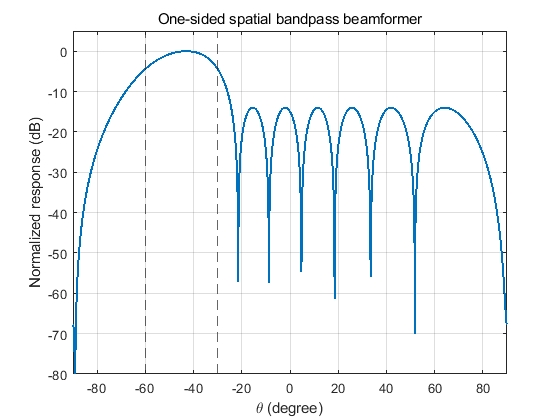

In [9]:

%% Beam response
P = wH*A;
BP = 20*log10(max(abs(P)/max(abs(P)), 1e-10));

figure;
plot(theta, BP, 'LineWidth', 1.5);
grid on;

xlim([-90 90]);
ylim([-80 5]);

xlabel('\theta (degree)');
ylabel('Normalized response (dB)');
title('One-sided spatial bandpass beamformer');

xline(-60, '--');
xline(-30, '--');


Use fir1 to design a beamformer whose passband is $[-20^{\circ } ,20^{\circ } ]$ . This is equivalent to a low\-pass filter with 12 array elements.


In [10]:
%% Array parameters
lambda = 3e-2;
M = 12;

theta = -90:0.1:90;
m = (0:M-1).';

%% Steering vector for a half-wavelength-spaced array
A = exp(-1j*pi*m*sind(theta));

%% Target angular interval
theta1 = -20;
theta2 = -20;

% u1 = sind(theta1);
% u2 = sind(theta2);

u1 = -0.342*pi;
u2 = 0.342*pi;

h0 = fir1(M-1,0.342,"low");

In [11]:

wH = h0;

disp('Complex beamformer weights w^H：');

Complex beamformer weights w^H：


In [12]:
disp(wH);

   -0.0017   -0.0107   -0.0184    0.0338    0.1780    0.3190    0.3190    0.1780    0.0338   -0.0184   -0.0107   -0.0017



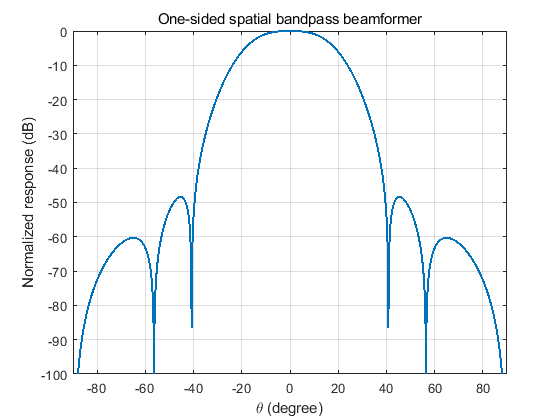

In [13]:

%% Beam response
P = wH*A;
BP = 20*log10(max(abs(P)/max(abs(P)), 1e-10));

figure;
plot(theta, BP, 'LineWidth', 1.5);
grid on;

xlim([-90 90]);
ylim([-100 0]);

xlabel('\theta (degree)');
ylabel('Normalized response (dB)');
title('One-sided spatial bandpass beamformer');




If the element spacing is less than half a wavelength, for example a quarter wavelength, the beam pattern with the same settings is:


In [14]:
%% Array parameters
lambda = 3e-2;
M = 12;

theta = -90:0.1:90;
m = (0:M-1).';
alpha = 1/2;
%% Steering vector for a half-wavelength-spaced array
A = exp(-1j*pi*alpha*m*sind(theta));

%% Target angular interval
theta1 = -20;
theta2 = 20;

u1 = alpha*sind(theta1);
u2 = alpha*sind(theta2);

% u1 = -0.342*pi;
% u2 = 0.342*pi;

h0 = fir1(M-1,u2,"low");

In [15]:

wH = h0;

disp('Complex beamformer weights w^H：');

Complex beamformer weights w^H：


In [16]:
disp(wH);

    0.0011    0.0088    0.0370    0.0920    0.1578    0.2032    0.2032    0.1578    0.0920    0.0370    0.0088    0.0011



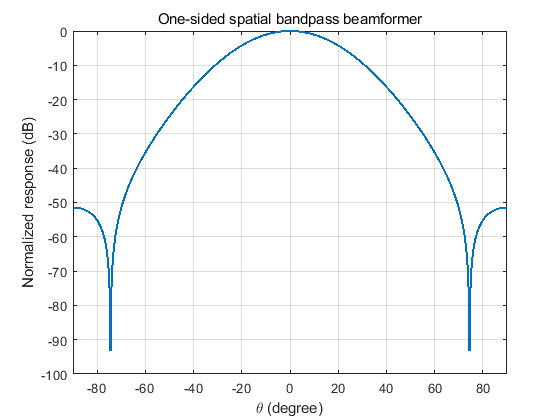

In [17]:

%% Beam response
P = wH*A;
BP = 20*log10(max(abs(P)/max(abs(P)), 1e-10));

figure;
plot(theta, BP, 'LineWidth', 1.5);
grid on;

xlim([-90 90]);
ylim([-100 0]);

xlabel('\theta (degree)');
ylabel('Normalized response (dB)');
title('One-sided spatial bandpass beamformer');